# 06c — LSTM (daily input, Friday-only weekly target)

Mixed-frequency neural extension of `06_lstm.ipynb`. Same weekly Friday-to-Friday silver-return
target and the **same 174 W-FRI evaluation dates** as every other model (directly comparable),
but the LSTM is fed **daily** sequences instead of weekly ones.

**Why this notebook.** A weekly LSTM sees ~355 weekly steps, one row per week — a thin use of a
sequence model. Here it ingests the daily path: the natural input for a recurrent net and the
neural analogue of the daily-MIDAS (`03b`). It also lets us train on ~5× more (overlapping) rows.

**Setup — overlapping train / Friday-only eval.**
- **Train (overlapping):** every trading day `t` is an origin — input = the last `LOOKBACK` daily
  rows ending at `t`; target = the cumulative silver return over the next `HORIZON=5` trading days.
  ~1,700 examples. Built per split, so no target spills across train/val/test.
- **Eval (Friday-only, non-overlapping):** at each test Friday, input = the last `LOOKBACK` daily
  rows ending on the **prior** Friday; target = the **canonical weekly `silver_return`** of that
  week (from `features_weekly.csv`). Exactly the 174 test Fridays used by ARIMA / XGB / RF /
  weekly-LSTM → apples-to-apples.

**Honest caveat (small-N).** Overlapping windows give the optimiser ~5× more rows, but adjacent
5-day targets share 4 of 5 days, so the *effective independent* sample is still ≈ the weekly count
(~340). This stabilises training; it does **not** add independent information about weekly returns
and is **not** expected to beat drift. It is the mixed-frequency neural extension — expect a
stronger semi-strong null, not a win.

**Holiday weeks.** The training target is a fixed 5-trading-day-ahead return; in ~33 holiday-shortened
weeks this differs slightly from the calendar week (corr 0.96 vs the canonical weekly) — inherent to
fixed-horizon overlapping targets. The **eval** target is always the canonical weekly return, so the
model comparison is unaffected.

**Features (daily).** From `data/processed/{train,val,test}.csv`: EXOG = silver + 6 cross-asset daily
returns; ablations add `gs_ratio_z`, squared returns (NonLin), the 3 FRED-daily changes, COT
positioning, and daily Reddit/News sentiment. **TECH and MACRO are omitted** — no daily series (TECH
is computed weekly, MACRO is monthly).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Hyperparameters

Defaults set in the next cell. **`LOOKBACK`, `HIDDEN`, `DROPOUT` are overwritten by the §4 grid
search** (tuned once on EXOG, reused across variants); the rest stay fixed.

| Param | Default | Tuned §4 | Role |
|---|---|:---:|---|
| `LOOKBACK` | 60 | ✓ | Daily lookback — past **trading days** per input sequence (≈3 months). The recurrent context the LSTM learns from. |
| `HORIZON` | 5 | — | Target horizon in **trading days** — cumulative next-5-day silver return (≈ one week). |
| `HIDDEN` | 32 | ✓ | LSTM hidden-state width. |
| `N_LAYERS` | 1 | — | Stacked LSTM layers. |
| `DROPOUT` | 0.2 | ✓ | Dropout passed to `nn.LSTM` (applies between stacked layers). |
| `EPOCHS` | 150 | — | Max epochs — early stopping usually triggers first. |
| `LR` | 1e-3 | — | Adam learning rate. |
| `PATIENCE` | 15 | — | Early-stopping patience on val loss. |
| `BATCH` | 32 | — | Mini-batch size — larger than the weekly notebook (~5× more sequences). |

In [2]:
LOOKBACK = 60    # daily lookback: 60 trading days (~3 months)
HORIZON  = 5     # 5 trading days ahead (~1 week)
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 32    # ~5x more sequences than the weekly notebook

TARGET = 'silver_return'

## 2. Load daily splits + canonical weekly target

Daily features from `data/processed/{train,val,test}.csv` feed the sequences. The canonical weekly
`silver_return` (= W-FRI sum of daily returns — verified identical) and the test Fridays come from
`features_weekly.csv`; they define the Friday-only eval target and the Drift floor.

In [3]:
# --- Daily feature splits (source of the sequences) ---
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

EXOG_RETURNS = ['gold_return','usd_return','copper_return','sp500_return','vix_return','oil_return']
MARKET    = [TARGET] + EXOG_RETURNS          # EXOG base = silver + 6 cross-asset DAILY returns
GS_COLS   = ['gs_ratio_z']
FRED_COLS = ['real_rates_chg','breakeven_chg','jobless_chg']
COT_COLS  = ['cot_mm_net_pct','cot_comm_net_pct']
SENT_COLS = ['reddit_sentiment','news_sentiment']
# Daily TECH (horizon-matched, built in 02_features §2) + monthly MACRO broadcast to daily (§2).
TECH_COLS  = ['macd_line_d', 'macd_hist_d', 'rsi_70d', 'mom_25d', 'roc_65d',
              'roc_130d', 'roc_260d', 'price_ma65d', 'donchian_260d', 'bb_pct_b_d']
MACRO_COLS = [f'{v}_mlag{k}' for v in ['cpi', 'fed_funds', 'ind_prod', 'm2'] for k in (1, 2, 3)]

# NonLin: squared daily returns (magnitude / vol info; the window supplies the lag).
for d in (train, val, test):
    for c in MARKET:
        d[f'{c}_sq'] = d[c] ** 2
SQ_COLS = [f'{c}_sq' for c in MARKET]

print(f'Daily rows  train={len(train)}  val={len(val)}  test={len(test)}')
print(f'Feature pool: EXOG{MARKET}')
print(f'  +GS{GS_COLS} +FRED{FRED_COLS} +COT{COT_COLS} +SENT{SENT_COLS} +SQ({len(SQ_COLS)})')
print(f'  +TECH({len(TECH_COLS)}) +MACRO({len(MACRO_COLS)})')

# --- Canonical weekly target + split labels (Friday-only eval target + Drift floor) ---
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)
wret   = weekly[TARGET].dropna().sort_index()                 # == W-FRI sum of daily returns
test_fridays = weekly[weekly['split'] == 'test'].index
test_fridays = test_fridays[test_fridays.isin(wret.index)]
print(f'Weekly test Fridays (eval targets): {len(test_fridays)}  '
      f'{test_fridays.min().date()}..{test_fridays.max().date()}')

Daily rows  train=1755  val=251  test=835
Feature pool: EXOG['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']
  +GS['gs_ratio_z'] +FRED['real_rates_chg', 'breakeven_chg', 'jobless_chg'] +COT['cot_mm_net_pct', 'cot_comm_net_pct'] +SENT['reddit_sentiment', 'news_sentiment'] +SQ(7)
  +TECH(10) +MACRO(12)
Weekly test Fridays (eval targets): 174  2023-01-06..2026-05-01


## 3. Architecture & helpers

`make_sequences` builds the **overlapping** training pairs (every daily origin → next-`HORIZON`
cumulative return). `friday_eval_sequences` builds the **non-overlapping** test pairs: window
ending the prior weekly Friday → canonical weekly return, warmed from the val tail so all 174 test
Fridays are predicted (val precedes test ⇒ no look-ahead).

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        # 1 layer keeps capacity low for the tiny sample. nn.LSTM's built-in dropout
        # is a no-op with num_layers=1 (it only acts BETWEEN stacked layers), so the
        # tuned `dropout` is applied explicitly on the final hidden state instead.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))


# Overlapping pairs: every origin t -> cumulative target over the next `horizon` rows.
def make_sequences(data, seq_len, target_col, horizon):
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# Friday-only test pairs: daily window ending the PRIOR weekly Friday -> canonical weekly return.
# Warmed from the val tail so all 174 test Fridays are predicted (val precedes test -> strictly
# past, no look-ahead). y is the raw weekly return (NOT scaled).
def friday_eval_sequences(scaler, cols, target_idx, seq_len):
    vt   = pd.concat([val, test])
    vt_s = scaler.transform(vt[cols].fillna(0))
    vt_i = vt.index
    X, y, dates = [], [], []
    for f in test_fridays:
        pos = wret.index.get_loc(f)
        if pos == 0:
            continue
        p = vt_i.searchsorted(wret.index[pos - 1], side='right') - 1   # last daily row <= prior Friday
        X.append(vt_s[p - seq_len + 1:p + 1])
        y.append(wret.loc[f])
        dates.append(f)
    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DatetimeIndex(dates))


LOSS_HISTORIES = {}   # variant -> {train, val, best_epoch}; for the §5b loss curves


def run_variant(name, feature_cols):
    print(f'\n{"=" * 50}\nVariant: {name}\n{"=" * 50}')
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    scaler = StandardScaler().fit(train[cols].fillna(0))            # fit on train only -> no leak
    tr_s   = scaler.transform(train[cols].fillna(0))
    va_s   = scaler.transform(val[cols].fillna(0))

    X_tr, y_tr = make_sequences(tr_s, LOOKBACK, target_idx, HORIZON)                  # overlapping train
    X_va, y_va = make_sequences(np.concatenate([tr_s[-(LOOKBACK - 1):], va_s]),       # val, warmed from train tail
                                LOOKBACK, target_idx, HORIZON)
    X_te, y_te, dates = friday_eval_sequences(scaler, cols, target_idx, LOOKBACK)     # Friday-only eval
    print(f'  Train seqs: {len(X_tr)} (overlapping)  Val: {len(X_va)}  Test Fridays: {len(X_te)}')

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)

    ckpt  = f'../../data/processed/lstm_{name.lower().replace("+","_").replace(" ","_")}_daily_best.pt'
    model = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    best_val, pat_cnt, best_epoch = np.inf, 0, 0
    hist_tr, hist_val = [], []   # loss curve, captured from the passes already run (no extra RNG)
    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_tr = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_tr.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in val_loader])
        sched.step(vl)
        hist_tr.append(float(np.mean(ep_tr)))
        hist_val.append(float(vl))
        if epoch % 25 == 0:
            print(f'  Epoch {epoch:3d}  val={vl:.6f}')
        if vl < best_val:
            best_val, pat_cnt, best_epoch = vl, 0, epoch
            torch.save(model.state_dict(), ckpt)
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break
    LOSS_HISTORIES[name] = {'train': hist_tr, 'val': hist_val, 'best_epoch': best_epoch}

    model.load_state_dict(torch.load(ckpt))
    model.eval()
    with torch.no_grad():
        preds_s = model(torch.tensor(X_te).to(DEVICE)).cpu().numpy().flatten()

    mu, sigma = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds     = preds_s * sigma + HORIZON * mu      # un-scale the H-step sum -> raw (~weekly) return
    actuals   = y_te                                 # canonical weekly return (already raw)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test predictions: {len(preds)} weekly Fridays')

    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates

## 4. Hyperparameter tuning

Mini-grid over `LOOKBACK`, `HIDDEN`, `DROPOUT` on the `EXOG` variant (silver + 6 cross-asset daily
returns), scored on overlapping-val loss with early stopping. Best config reused across all
variants — matching the weekly notebook (tune the model class once, test feature additions on top).
`LOOKBACK` is the one genuinely daily-specific knob: how many trading days of context the LSTM sees.

In [5]:
from itertools import product

LOOKBACK_GRID = [20, 40, 60]      # daily lookback (~1 / 2 / 3 months)
HIDDEN_GRID   = [16, 32]
DROPOUT_GRID  = [0.1, 0.2, 0.3]

tune_cols = MARKET                # EXOG base (silver + 6 cross-asset daily returns)


# Train one config on overlapping train pairs; return best (overlapping) val loss.
def eval_config(lookback, hidden, dropout):
    scaler_t = StandardScaler().fit(train[tune_cols].fillna(0))
    tr_s_t   = scaler_t.transform(train[tune_cols].fillna(0))
    va_s_t   = scaler_t.transform(val[tune_cols].fillna(0))
    tidx     = tune_cols.index(TARGET)

    X_tr, y_tr = make_sequences(tr_s_t, lookback, tidx, HORIZON)
    X_va, y_va = make_sequences(np.concatenate([tr_s_t[-(lookback - 1):], va_s_t]),
                                lookback, tidx, HORIZON)
    if len(X_tr) == 0 or len(X_va) == 0:
        return np.inf

    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)),
                           batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va).unsqueeze(1)),
                           batch_size=BATCH, shuffle=False)

    model = LSTMForecaster(len(tune_cols), hidden, N_LAYERS, dropout).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()

    best_vl, pat = np.inf, 0
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in va_loader])
        if vl < best_vl:
            best_vl, pat = vl, 0
        else:
            pat += 1
            if pat >= PATIENCE:
                break
    return best_vl


configs = list(product(LOOKBACK_GRID, HIDDEN_GRID, DROPOUT_GRID))
print(f'Tuning on EXOG variant ({len(tune_cols)} features) - {len(configs)} configs')
print('-' * 60)

search = []
for lookback, hidden, dropout in configs:
    vl = eval_config(lookback, hidden, dropout)
    print(f'  LOOKBACK={lookback:>3}  HIDDEN={hidden:>3}  DROPOUT={dropout}  val_loss={vl:.6f}')
    search.append({'lookback': lookback, 'hidden': hidden, 'dropout': dropout, 'val_loss': vl})

best = min(search, key=lambda r: r['val_loss'])
print(f'\nBest:  LOOKBACK={best["lookback"]}  HIDDEN={best["hidden"]}'
      f'  DROPOUT={best["dropout"]}  val_loss={best["val_loss"]:.6f}')

LOOKBACK, HIDDEN, DROPOUT = best['lookback'], best['hidden'], best['dropout']

Tuning on EXOG variant (7 features) - 18 configs
------------------------------------------------------------
  LOOKBACK= 20  HIDDEN= 16  DROPOUT=0.1  val_loss=6.716489
  LOOKBACK= 20  HIDDEN= 16  DROPOUT=0.2  val_loss=6.708457
  LOOKBACK= 20  HIDDEN= 16  DROPOUT=0.3  val_loss=6.764170
  LOOKBACK= 20  HIDDEN= 32  DROPOUT=0.1  val_loss=6.719183
  LOOKBACK= 20  HIDDEN= 32  DROPOUT=0.2  val_loss=6.729085
  LOOKBACK= 20  HIDDEN= 32  DROPOUT=0.3  val_loss=6.751190
  LOOKBACK= 40  HIDDEN= 16  DROPOUT=0.1  val_loss=6.735934
  LOOKBACK= 40  HIDDEN= 16  DROPOUT=0.2  val_loss=6.501766
  LOOKBACK= 40  HIDDEN= 16  DROPOUT=0.3  val_loss=6.752505
  LOOKBACK= 40  HIDDEN= 32  DROPOUT=0.1  val_loss=6.750199
  LOOKBACK= 40  HIDDEN= 32  DROPOUT=0.2  val_loss=6.733709
  LOOKBACK= 40  HIDDEN= 32  DROPOUT=0.3  val_loss=6.761335
  LOOKBACK= 60  HIDDEN= 16  DROPOUT=0.1  val_loss=6.714892
  LOOKBACK= 60  HIDDEN= 16  DROPOUT=0.2  val_loss=6.716391
  LOOKBACK= 60  HIDDEN= 16  DROPOUT=0.3  val_loss=6.738319
  LOO

## 5. Train variants

Daily feature-group ladder, mirroring the weekly notebook for every rung that has a daily series.
**`Y`** = silver only (own-history / weak form); **`EXOG`** = silver + 6 cross-asset daily returns;
then `+GS`, `+NonLin` (squared returns), `+FRED`, `+COT`, the sentiment rungs, and `+ALL`.
TECH and MACRO are dropped (no daily series). Each variant trains once on the overlapping pairs and
predicts the 174 test Fridays.

In [6]:
MARKET_FEATURES = MARKET   # EXOG base (silver + 6 cross-asset daily returns)

variants = {
    'LSTM-d-Y':                     [TARGET],
    'LSTM-d-TECH':                  [TARGET] + TECH_COLS,
    'LSTM-d-EXOG':                  MARKET_FEATURES,
    'LSTM-d-EXOG-GS':               MARKET_FEATURES + GS_COLS,
    'LSTM-d-EXOG-NONLIN':           MARKET_FEATURES + SQ_COLS,
    'LSTM-d-EXOG-TECH':             MARKET_FEATURES + TECH_COLS,
    'LSTM-d-EXOG-MACRO':            MARKET_FEATURES + MACRO_COLS,
    'LSTM-d-EXOG-FRED':             MARKET_FEATURES + FRED_COLS,
    'LSTM-d-EXOG-COT':              MARKET_FEATURES + COT_COLS,
    'LSTM-d-EXOG-FRED-COT':         MARKET_FEATURES + FRED_COLS + COT_COLS,
    'LSTM-d-EXOG-REDDIT':           MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-d-EXOG-NEWS':             MARKET_FEATURES + ['news_sentiment'],
    'LSTM-d-EXOG-SENTIMENT':        MARKET_FEATURES + SENT_COLS,
    'LSTM-d-EXOG-GS-SENTIMENT':     MARKET_FEATURES + GS_COLS + SENT_COLS,
    'LSTM-d-EXOG-NONLIN-SENTIMENT': MARKET_FEATURES + SQ_COLS + SENT_COLS,
    'LSTM-d-EXOG-TECH-SENTIMENT':   MARKET_FEATURES + TECH_COLS + SENT_COLS,
    # Kitchen sink: GS + NonLin + Tech + FRED + COT + Sentiment (MACRO left out, mirroring 06's ALL).
    'LSTM-d-EXOG-ALL':              MARKET_FEATURES + GS_COLS + SQ_COLS + TECH_COLS + FRED_COLS + COT_COLS + SENT_COLS,
}

results     = {}
all_preds   = {}
actuals_arr = None
dates_arr   = None

for name, cols in variants.items():
    m, preds, acts, dates = run_variant(name, cols)
    results[name]   = m
    all_preds[name] = preds
    actuals_arr     = acts
    dates_arr       = dates


Variant: LSTM-d-Y
  Train seqs: 1711 (overlapping)  Val: 246  Test Fridays: 174
  Early stopping at epoch 20
  RMSE=0.051802  MAE=0.037197  DA=0.569  WDA=0.629
  Test predictions: 174 weekly Fridays

Variant: LSTM-d-TECH
  Train seqs: 1711 (overlapping)  Val: 246  Test Fridays: 174
  Early stopping at epoch 19
  RMSE=0.052221  MAE=0.037397  DA=0.494  WDA=0.487
  Test predictions: 174 weekly Fridays

Variant: LSTM-d-EXOG
  Train seqs: 1711 (overlapping)  Val: 246  Test Fridays: 174
  Epoch  25  val=6.585099
  Early stopping at epoch 35
  RMSE=0.052457  MAE=0.037988  DA=0.466  WDA=0.466
  Test predictions: 174 weekly Fridays

Variant: LSTM-d-EXOG-GS
  Train seqs: 1711 (overlapping)  Val: 246  Test Fridays: 174
  Early stopping at epoch 17
  RMSE=0.051758  MAE=0.036972  DA=0.523  WDA=0.519
  Test predictions: 174 weekly Fridays

Variant: LSTM-d-EXOG-NONLIN
  Train seqs: 1711 (overlapping)  Val: 246  Test Fridays: 174
  Early stopping at epoch 17
  RMSE=0.051792  MAE=0.037165  DA=0.557  W

## 5b. Training diagnostics — loss curves

Per-epoch **train vs validation MSE** (standardised ~weekly returns), captured during §5 at no cost.
Variants are **ranked by their best (minimum) validation loss**; the lowest is highlighted in the
right panel and shown train-vs-val on the left (dashed line = early-stopping `best_epoch`).

> Note the whole band sits **above ~1.0** (= predicting the train mean), so even the "best"
> variant has *negative* out-of-sample R² — "converges lower" means *less bad*, not skill. It
> still has to beat the Drift on the **test** set (§6/§9), which it doesn't.

In [ ]:
# Loss curves from the §5 training runs (LOSS_HISTORIES populated by run_variant).
assert LOSS_HISTORIES, 'Run §5 (Train variants) first to populate LOSS_HISTORIES.'

# Rank variants by the best (minimum) validation loss they reach -- this NAMES the
# variant whose curve looks like it "converges" lowest in the overlay.
rank = sorted(LOSS_HISTORIES, key=lambda n: min(LOSS_HISTORIES[n]['val']))
print(f'{"rank":>4}  {"variant":<30}  {"min val":>8}  {"@epoch":>6}  {"final val":>9}')
print('-' * 66)
for i, n in enumerate(rank, 1):
    v = LOSS_HISTORIES[n]['val']
    print(f'{i:>4}  {n:<30}  {min(v):>8.4f}  {int(np.argmin(v)) + 1:>6}  {v[-1]:>9.4f}')
best = rank[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) the lowest-min-val variant: train vs val (does its 'convergence' hold up?)
h  = LOSS_HISTORIES[best]
ep = range(1, len(h['train']) + 1)
axes[0].plot(ep, h['train'], color='#1f77b4', label='train')
axes[0].plot(ep, h['val'],   color='#d62728', label='val')
axes[0].axvline(h['best_epoch'], color='grey', ls='--', lw=1, label=f"best epoch ({h['best_epoch']})")
axes[0].set(title=f'{best} — MSE loss (standardised returns)', xlabel='epoch', ylabel='MSE')
axes[0].legend(fontsize=8)

# (b) all variants' val loss; lowest-min highlighted, rest greyed (de-clutters the overlay)
for n in rank:
    if n == best:
        continue
    v = LOSS_HISTORIES[n]['val']
    axes[1].plot(range(1, len(v) + 1), v, color='0.75', lw=0.8, alpha=0.7, zorder=1)
vb = LOSS_HISTORIES[best]['val']
axes[1].plot(range(1, len(vb) + 1), vb, color='#d62728', lw=2.0, zorder=3,
             label=f'best: {best} (min {min(vb):.4f})')
axes[1].axhline(1.0, color='black', lw=0.7, ls=':', zorder=2, label='predict-mean (MSE=1)')
axes[1].set(title=f'Validation loss — {len(rank)} variants (lowest-min highlighted)',
            xlabel='epoch', ylabel='val MSE')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Results

**Metrics** — RMSE / MAE (magnitude), OOS R² (effect size vs Drift, shown as `r2_os` below), DA / WDA (direction). Formulas, caveats, and load-bearing status: `01_arima` §5 or [`tests.md`](tests.md).

In [7]:
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import oos_r2, period_metrics, diebold_mariano, PERIODS

# Naive baseline: predict y_t = y_{t-1}.
naive_pred = np.concatenate([[np.nan], actuals_arr[:-1]])
mask       = ~np.isnan(naive_pred)
n_acts     = actuals_arr[mask]
n_preds    = naive_pred[mask]

naive_row = {
    'model':   'Naive (t-1 week)',
    'rmse':    float(np.sqrt(mean_squared_error(n_acts, n_preds))),
    'mae':     float(mean_absolute_error(n_acts, n_preds)),
    'r2_os':   float('nan'),   # different effective length -- not comparable
    'dir_acc': float(np.mean(np.sign(n_acts) == np.sign(n_preds))),
    'wda':     float(np.sum(np.abs(n_acts) * (np.sign(n_acts) == np.sign(n_preds))) / np.sum(np.abs(n_acts))),
}

# Drift / random-walk-with-drift: prevailing (expanding) mean of weekly returns,
# aligned to LSTM test dates (strictly past returns -- no look-ahead). EMH floor:
# ARIMA(0,0,0) by construction; directionally always-up. OOS R^2 = 0 by definition.
_ret       = weekly['silver_return'].dropna().sort_index()
drift_pred = np.array([_ret[_ret.index < d].mean() for d in pd.DatetimeIndex(dates_arr)])
drift_row  = {
    'model':   'Drift (prevailing mean)',
    'rmse':    float(np.sqrt(mean_squared_error(actuals_arr, drift_pred))),
    'mae':     float(mean_absolute_error(actuals_arr, drift_pred)),
    'r2_os':   0.0,
    'dir_acc': float(np.mean(np.sign(actuals_arr) == np.sign(drift_pred))),
    'wda':     float(np.sum(np.abs(actuals_arr) * (np.sign(actuals_arr) == np.sign(drift_pred))) / np.sum(np.abs(actuals_arr))),
}

# All variants -- r2_os: % MSE reduction vs Drift (Campbell-Thompson 2008); >0 beats random walk.
variant_rows = []
for name, row in results.items():
    r = dict(row)
    r['r2_os'] = oos_r2(actuals_arr, all_preds[name], drift_pred) * 100
    variant_rows.append(r)

metrics_df = pd.DataFrame([naive_row, drift_row] + variant_rows)
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]
metrics_df.to_csv('../../data/processed/metrics_lstm_daily_weekly.csv', index=False)

print(f'{"Model":<30}  {"RMSE":>10}  {"MAE":>10}  {"R2_OS":>7}  {"DA":>6}  {"WDA":>6}')
print('-' * 78)
for _, row in metrics_df.iterrows():
    r2 = f'{row["r2_os"]:>+7.2f}' if not pd.isna(row['r2_os']) else '   n/a'
    print(f'{row["model"]:<30}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {r2:>7}  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')

Model                                 RMSE         MAE    R2_OS      DA     WDA
------------------------------------------------------------------------------
Naive (t-1 week)                  0.075941    0.053966      n/a   0.491   0.490
Drift (prevailing mean)           0.051902    0.037135    +0.00   0.557   0.588
LSTM-d-Y                          0.051802    0.037197    +0.38   0.569   0.629
LSTM-d-TECH                       0.052221    0.037397    -1.23   0.494   0.487
LSTM-d-EXOG                       0.052457    0.037988    -2.15   0.466   0.466
LSTM-d-EXOG-GS                    0.051758    0.036972    +0.55   0.523   0.519
LSTM-d-EXOG-NONLIN                0.051792    0.037165    +0.42   0.557   0.588
LSTM-d-EXOG-TECH                  0.052157    0.037459    -0.99   0.500   0.511
LSTM-d-EXOG-MACRO                 0.051616    0.037502    +1.10   0.557   0.624
LSTM-d-EXOG-FRED                  0.052084    0.037357    -0.70   0.471   0.502
LSTM-d-EXOG-COT                   0.05218

## 7. Sub-period robustness + best-variant selection

In [8]:
def _period_r2_lstm(pred):
    drift_s = pd.Series(drift_pred, index=pd.DatetimeIndex(dates_arr))
    pred_s  = pd.Series(pred,       index=pd.DatetimeIndex(dates_arr))
    yt_s    = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y, _p, _d = yt_s.loc[_a:_b].values, pred_s.loc[_a:_b].values, drift_s.loc[_a:_b].values
        if len(_y): r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period_lstm(pred, csv=None):
    res = period_metrics(actuals_arr, pred, dates_arr, PERIODS)
    r2  = _period_r2_lstm(pred)
    res['R2_OS'] = [r2.get(lbl, float('nan')) for lbl in res.index]
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}',
                     'R2_OS': '{:+.2f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
    if csv:
        res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema

def _save_preds_lstm(pred, csv):
    pd.DataFrame({'actual': actuals_arr, 'predicted': pred},
                 index=pd.DatetimeIndex(dates_arr)).rename_axis('Date').to_csv(csv)

best_name      = max(results, key=lambda k: results[k]['wda'])
best_name_rmse = min(results, key=lambda k: results[k]['rmse'])
best_pred      = all_preds[best_name]
best_pred_rmse = all_preds[best_name_rmse]
print(f'Best variant -- WDA: {best_name}  |  RMSE: {best_name_rmse}')

# Drift by period -- the floor (constant-sign, always-up; its DA/WDA = the up-share).
print('\nDrift (prevailing mean) by period -- the floor:')
_show_period_lstm(drift_pred)

print('\nWDA-best by period:')
_show_period_lstm(best_pred, '../../data/processed/period_lstm_daily_weekly.csv')
print('RMSE-best by period:')
_show_period_lstm(best_pred_rmse, '../../data/processed/period_lstm_daily_rmse_weekly.csv')

_save_preds_lstm(best_pred,      '../../data/processed/preds_lstm_daily_best_weekly.csv')
_save_preds_lstm(best_pred_rmse, '../../data/processed/preds_lstm_daily_bestrmse_weekly.csv')
print('\nSaved: period + preds (WDA-best legacy names, RMSE-best alongside).')

# Drift WDA by period (the directional benchmark to beat).
_yt = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = _yt.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')


Best variant -- WDA: LSTM-d-Y  |  RMSE: LSTM-d-EXOG-MACRO

Drift (prevailing mean) by period -- the floor:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,+0.00,0.500,0.570
2025 (bull run),52,0.0498,0.0352,+0.00,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,+0.00,0.557,0.588



WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0399,0.0318,+0.31,0.500,0.499
2024 (bull start),52,0.0381,0.0301,-0.62,0.500,0.566
2025 (bull run),52,0.0498,0.0352,+0.05,0.673,0.729
2026 (YTD),18,0.0998,0.0792,+1.08,0.667,0.719
── Full test ──,174,0.0518,0.0372,+0.38,0.569,0.629


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0413,0.0328,-6.68,0.481,0.492
2024 (bull start),52,0.0385,0.0312,-2.92,0.500,0.570
2025 (bull run),52,0.0478,0.0342,+7.87,0.673,0.747
2026 (YTD),18,0.0996,0.0787,+1.51,0.611,0.675
── Full test ──,174,0.0516,0.0375,+1.10,0.557,0.624



Saved: period + preds (WDA-best legacy names, RMSE-best alongside).

Drift WDA by period (directional benchmark to beat):
  2023  (choppy)       WDA=0.492  (n=52)
  2024  (bull start)   WDA=0.570  (n=52)
  2025  (bull run)     WDA=0.757  (n=52)
  2026  (YTD)          WDA=0.498  (n=18)
  ── Full test ──      WDA=0.588  (n=174)


## 8. Predicted vs actual — best variants

Two panels: WDA-best (directional pick) and RMSE-best (magnitude pick), each plotted against
the actual return and the Drift floor. Drift is constant-positive — its curve shows where an
always-up call would sit.

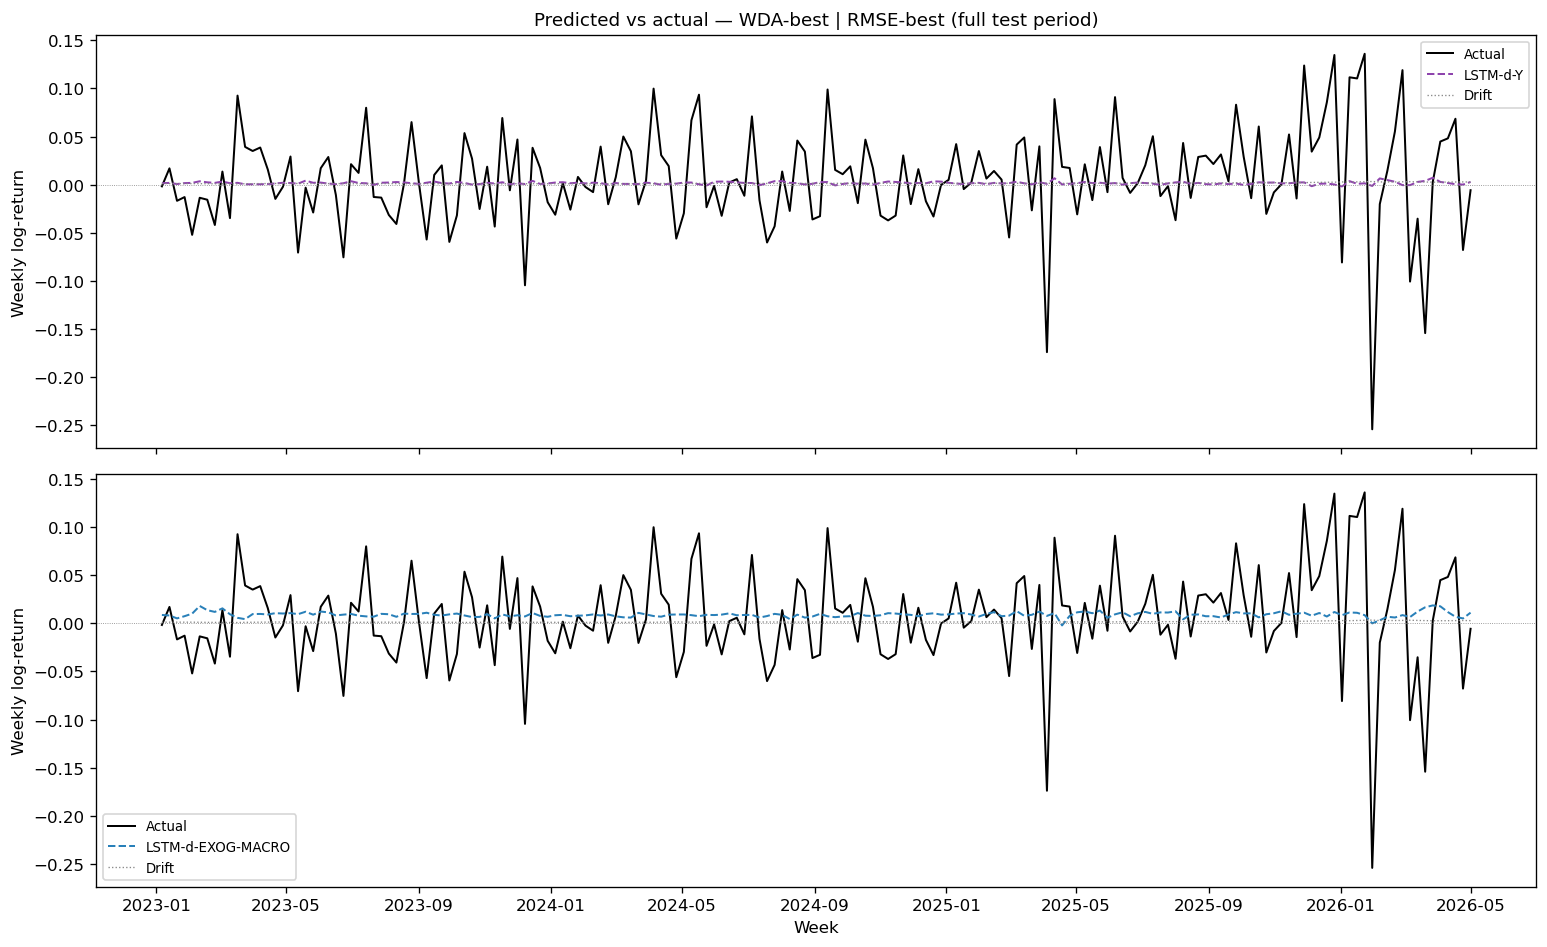

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

_idx   = pd.DatetimeIndex(dates_arr)
_act   = pd.Series(actuals_arr,  index=_idx)
_drift = pd.Series(drift_pred,   index=_idx)
_wda   = pd.Series(best_pred,    index=_idx)
_rmse  = pd.Series(best_pred_rmse, index=_idx)

for ax, pred_s, label, color in [
    (axes[0], _wda,  best_name,      '#8e44ad'),
    (axes[1], _rmse, best_name_rmse, '#2980b9'),
]:
    ax.plot(_idx, _act,   color='black',  lw=1.2, label='Actual')
    ax.plot(_idx, pred_s, color=color,    lw=1.2, ls='--', label=label)
    ax.plot(_idx, _drift, color='#888',   lw=0.8, ls=':',  label='Drift')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.set_ylabel('Weekly log-return')
    ax.legend(fontsize=8)

axes[0].set_title('Predicted vs actual — WDA-best | RMSE-best (full test period)', fontsize=11)
axes[1].set_xlabel('Week')
plt.tight_layout()
plt.show()


## 9. Significance tests

### DM — squared-error floor (load-bearing)

The headline test: does any variant produce significantly lower **squared** forecast errors than
the Drift? This is the proper significance test for the OOS R² in §6 (both MSFE-based).

In [10]:
# Semi-strong floor [PRIMARY] — squared-error loss vs Drift.
# DM is the significance test for the OOS R^2 in §6 (both MSFE-based).
print("Diebold-Mariano -- vs Drift floor   [squared error]")
print("Semi-strong test: can any variant beat the no-predictability drift?")
print("-" * 90)
for name, pred in all_preds.items():
    diebold_mariano(actuals_arr, drift_pred, pred, "Drift", name)

Diebold-Mariano -- vs Drift floor   [squared error]
Semi-strong test: can any variant beat the no-predictability drift?
------------------------------------------------------------------------------------------
Drift                                    vs LSTM-d-Y                                  DM=+0.733  p=0.463  (ns)  -> winner: tie
Drift                                    vs LSTM-d-TECH                               DM=-0.761  p=0.447  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG                               DM=-0.737  p=0.461  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-GS                            DM=+0.514  p=0.607  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-NONLIN                        DM=+0.941  p=0.347  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-TECH                          DM=-1.773  p=0.076  (ns)  -> winner: tie
Drift                      

### DM — absolute-error (robustness)

Same framework, loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Weekly silver returns
are heavy-tailed — a few outlier weeks dominate squared loss. Absolute-error checks whether
the result survives a less outlier-sensitive criterion. Squared error stays the headline.

In [11]:
# Robustness -- floor test under ABSOLUTE-error loss.
print("Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]")
print("-" * 90)
for name, pred in all_preds.items():
    diebold_mariano(actuals_arr, drift_pred, pred, "Drift", name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
------------------------------------------------------------------------------------------
Drift                                    vs LSTM-d-Y                                  DM=-0.652  p=0.515  (ns)  -> winner: tie
Drift                                    vs LSTM-d-TECH                               DM=-0.725  p=0.468  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG                               DM=-1.380  p=0.168  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-GS                            DM=+0.878  p=0.380  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-NONLIN                        DM=-0.219  p=0.827  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-TECH                          DM=-1.845  p=0.065  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-MACRO                

## 9b. Directional test — Pesaran–Timmermann (secondary lens)

In [12]:
from eval_utils import pesaran_timmermann

print("Pesaran-Timmermann directional test — full test window")
print("H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001")
print("-" * 90)
pesaran_timmermann(actuals_arr, drift_pred, name="Drift (always-up)")   # degenerate ref
pt_results = {n: pesaran_timmermann(actuals_arr, p, name=n) for n, p in all_preds.items()}
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f"\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 "
      f"(~{0.05 * len(_tested):.1f} expected by chance): {list(_sig)}")

print(f"\nPer-period PT — {best_name}:")
_yt = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
_bp = pd.Series(best_pred, index=pd.DatetimeIndex(dates_arr))
for _lbl, (_a, _b) in PERIODS.items():
    _yy = _yt.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f"  {_lbl}  (n={len(_yy)})")

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001
------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
LSTM-d-Y                                  DA=0.569  DA|indep=0.550  PT=+1.021  p=0.307  (ns)  -> winner: tie (chance)
LSTM-d-TECH                               DA=0.494  DA|indep=0.471  PT=+0.720  p=0.472  (ns)  -> winner: tie (chance)
LSTM-d-EXOG                               DA=0.466  DA|indep=0.493  PT=-0.731  p=0.465  (ns)  -> winner: tie (chance)
LSTM-d-EXOG-GS                            DA=0.523  DA|indep=0.544  PT=-0.888  p=0.374  (ns)  -> winner: tie (chance)
LSTM-d-EXOG-NONLIN                        DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
LSTM-d-EXOG-TECH                          DA=0.500  DA|ind

## 9c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up directional line, so once the full-window tests are done,
re-run **the whole battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026**
only. Evaluation-only (models unchanged); pooled (per-year DM is underpowered). The efficiency
conclusion *strengthens* once the bull is removed.

In [13]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window — evaluation only, forecasts unchanged.
mask_ex25 = np.array(pd.DatetimeIndex(dates_arr).year != 2025)
a_ex      = actuals_arr[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
dates_ex  = pd.DatetimeIndex(dates_arr)[mask_ex25]
_preds_ex = {name: np.asarray(pred)[mask_ex25] for name, pred in all_preds.items()}
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
from sklearn.metrics import mean_squared_error, mean_absolute_error
for name, pred_ex in _preds_ex.items():
    rmse = np.sqrt(mean_squared_error(a_ex, pred_ex))
    mae  = mean_absolute_error(a_ex, pred_ex)
    da   = np.mean(np.sign(a_ex) == np.sign(pred_ex))
    wda  = np.sum(np.abs(a_ex) * (np.sign(a_ex) == np.sign(pred_ex))) / np.sum(np.abs(a_ex))
    print(f'{name:<35}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')

print('\nOOS R^2 vs Drift (2025 excluded):')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    _r2 = oos_r2(a_ex, pred_ex, drift_ex) * 100
    print(f'  {name:35s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    diebold_mariano(a_ex, drift_ex, pred_ex, 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    diebold_mariano(a_ex, drift_ex, pred_ex, 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded):')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    pesaran_timmermann(a_ex, pred_ex, name=name)


Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
LSTM-d-Y                             RMSE=0.05262  MAE=0.03804  DA=0.525  WDA=0.589
LSTM-d-TECH                          RMSE=0.05225  MAE=0.03748  DA=0.533  WDA=0.548
LSTM-d-EXOG                          RMSE=0.05333  MAE=0.03852  DA=0.475  WDA=0.444
LSTM-d-EXOG-GS                       RMSE=0.05253  MAE=0.03784  DA=0.484  WDA=0.489
LSTM-d-EXOG-NONLIN                   RMSE=0.05276  MAE=0.03814  DA=0.500  WDA=0.520
LSTM-d-EXOG-TECH                     RMSE=0.05284  MAE=0.03804  DA=0.492  WDA=0.480
LSTM-d-EXOG-MACRO                    RMSE=0.05314  MAE=0.03892  DA=0.508  WDA=0.575
LSTM-d-EXOG-FRED                     RMSE=0.05269  MAE=0.03801  DA=0.467  WDA=0.519
LSTM-d-EXOG-COT                      RMSE=0.05367  MAE=0.03968  DA=0.475  WDA=0.518
LSTM-d-EXOG-REDDIT                   RMSE=0.05275  MAE=0.03795  DA=0.541  WDA=0.536
LSTM-d-EXOG-NEWS                     RMSE=0.05265  MAE=0.

## 10. 2026 zoom — actual vs best variants

Most recent out-of-sample slice, where silver has been most active. Two panels: WDA-best
(directional pick) and RMSE-best (magnitude pick), each with the Drift floor overlaid.

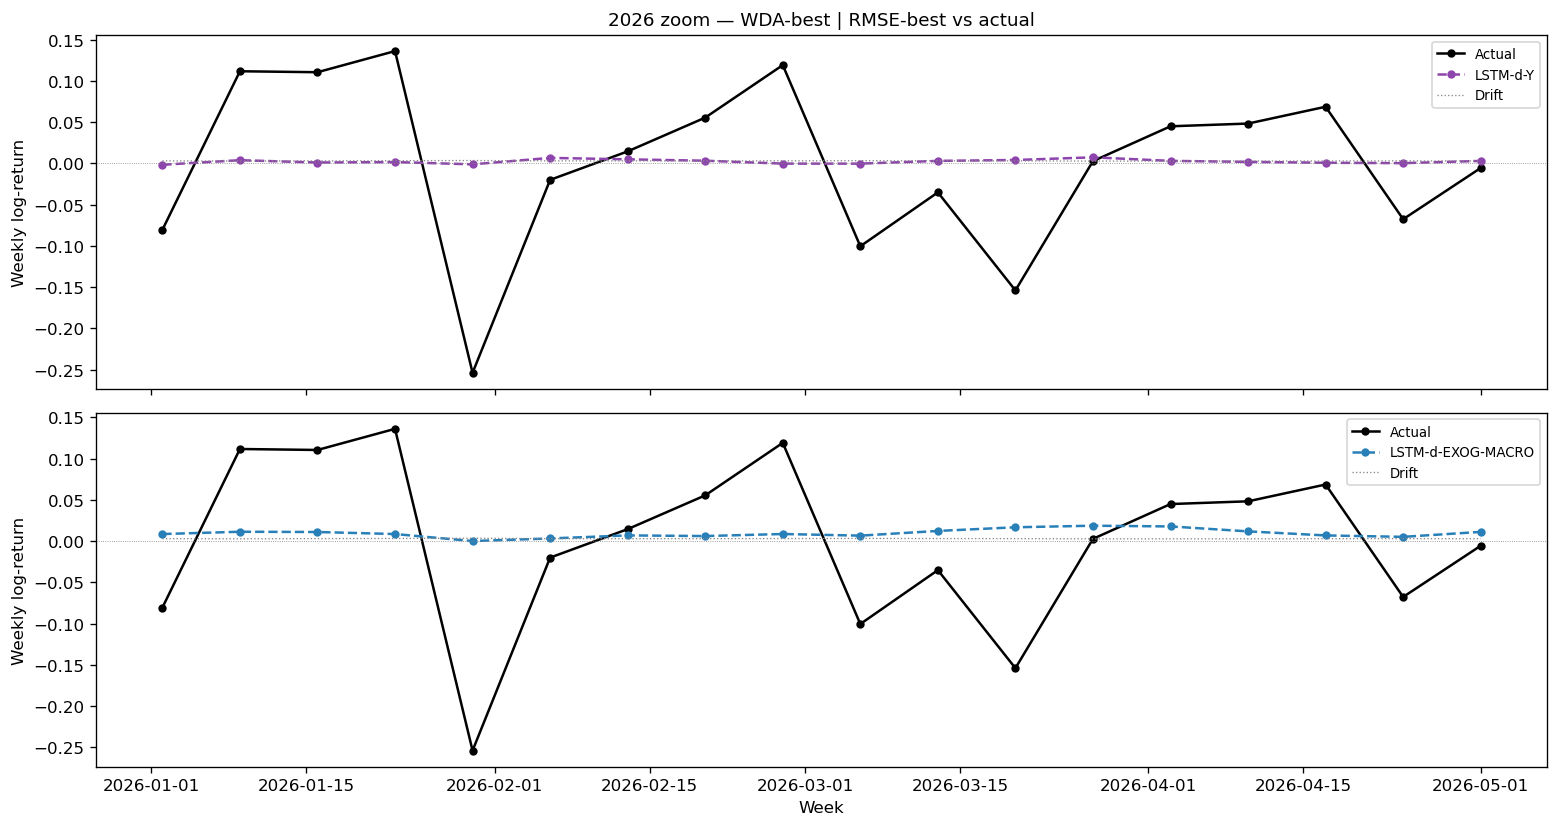

In [14]:
_idx26  = pd.DatetimeIndex(dates_arr)
_mask26 = _idx26.year == 2026

if _mask26.sum() == 0:
    print('No 2026 data in test set yet.')
else:
    _act26   = actuals_arr[_mask26]
    _drift26 = drift_pred[_mask26]
    _wda26   = best_pred[_mask26]
    _rmse26  = best_pred_rmse[_mask26]
    _dates26 = _idx26[_mask26]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ax, pred26, label, color in [
        (axes[0], _wda26,  best_name,      '#8e44ad'),
        (axes[1], _rmse26, best_name_rmse, '#2980b9'),
    ]:
        ax.plot(_dates26, _act26,   color='black', lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(_dates26, pred26,   color=color,   lw=1.5, marker='o', ms=4, ls='--', label=label)
        ax.plot(_dates26, _drift26, color='#888',  lw=0.8, ls=':',               label='Drift')
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.set_ylabel('Weekly log-return')
        ax.legend(fontsize=8)

    axes[0].set_title('2026 zoom — WDA-best | RMSE-best vs actual', fontsize=11)
    axes[1].set_xlabel('Week')
    plt.tight_layout()
    plt.show()
